# Departamento de marketing

- Dados: https://www.kaggle.com/arjunbhasin2013/ccdata


## Importação das bibliotecas e base de dados

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
creditcard_df = pd.read_csv('/kaggle/input/ccdata/CC GENERAL.csv')

In [3]:
creditcard_df.shape

(8950, 18)

In [4]:
creditcard_df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
creditcard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
creditcard_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
creditcard_df[creditcard_df['ONEOFF_PURCHASES'] == 40761.250000]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
550,C10574,11547.52001,1.0,49039.57,40761.25,8278.32,558.166886,1.0,1.0,0.916667,0.083333,1,101,22500.0,46930.59824,2974.069421,0.25,12


In [8]:
creditcard_df[creditcard_df['CASH_ADVANCE'] == 47137.211760]

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
2159,C12226,10905.05381,1.0,431.93,133.5,298.43,47137.21176,0.583333,0.25,0.5,1.0,123,21,19600.0,39048.59762,5394.173671,0.0,12


## Visualização e exploração dos dados

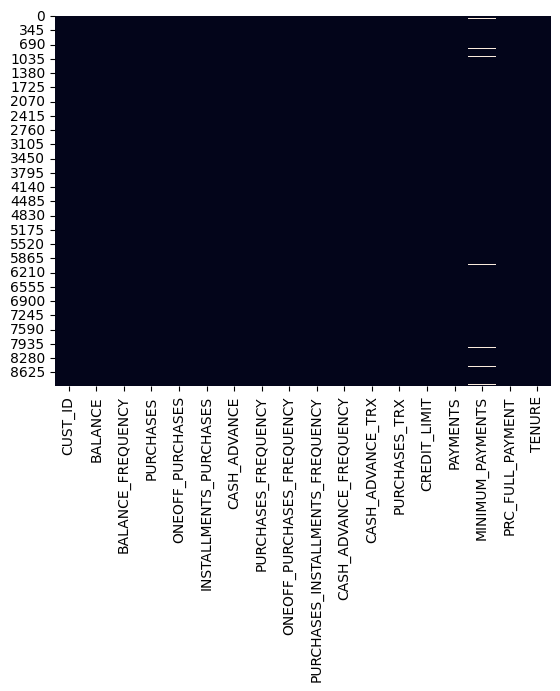

In [9]:
sns.heatmap(creditcard_df.isnull(), cbar=False);

In [10]:
creditcard_df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [11]:
creditcard_df['MINIMUM_PAYMENTS'].mean()

np.float64(864.2065423050828)

In [12]:
creditcard_df.loc[(creditcard_df['MINIMUM_PAYMENTS'].isnull() == True), 'MINIMUM_PAYMENTS'] = creditcard_df['MINIMUM_PAYMENTS'].mean()

In [13]:
creditcard_df['CREDIT_LIMIT'].mean()

np.float64(4494.449450364621)

In [14]:
creditcard_df.loc[(creditcard_df['CREDIT_LIMIT'].isnull() == True), 'CREDIT_LIMIT'] = creditcard_df['CREDIT_LIMIT'].mean()

In [15]:
creditcard_df.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [16]:
creditcard_df.duplicated().sum()

np.int64(0)

In [17]:
creditcard_df.drop('CUST_ID', axis=1, inplace = True)

In [18]:
creditcard_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [19]:
creditcard_df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

In [20]:
len(creditcard_df.columns)

17

/tmp/ipykernel_24/3296169916.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(creditcard_df[creditcard_df.columns[i]], kde = True)
/tmp/ipykernel_24/3296169916.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(creditcard_df[creditcard_df.columns[i]], kde = True)
/tmp/ipykernel_24/3296169916

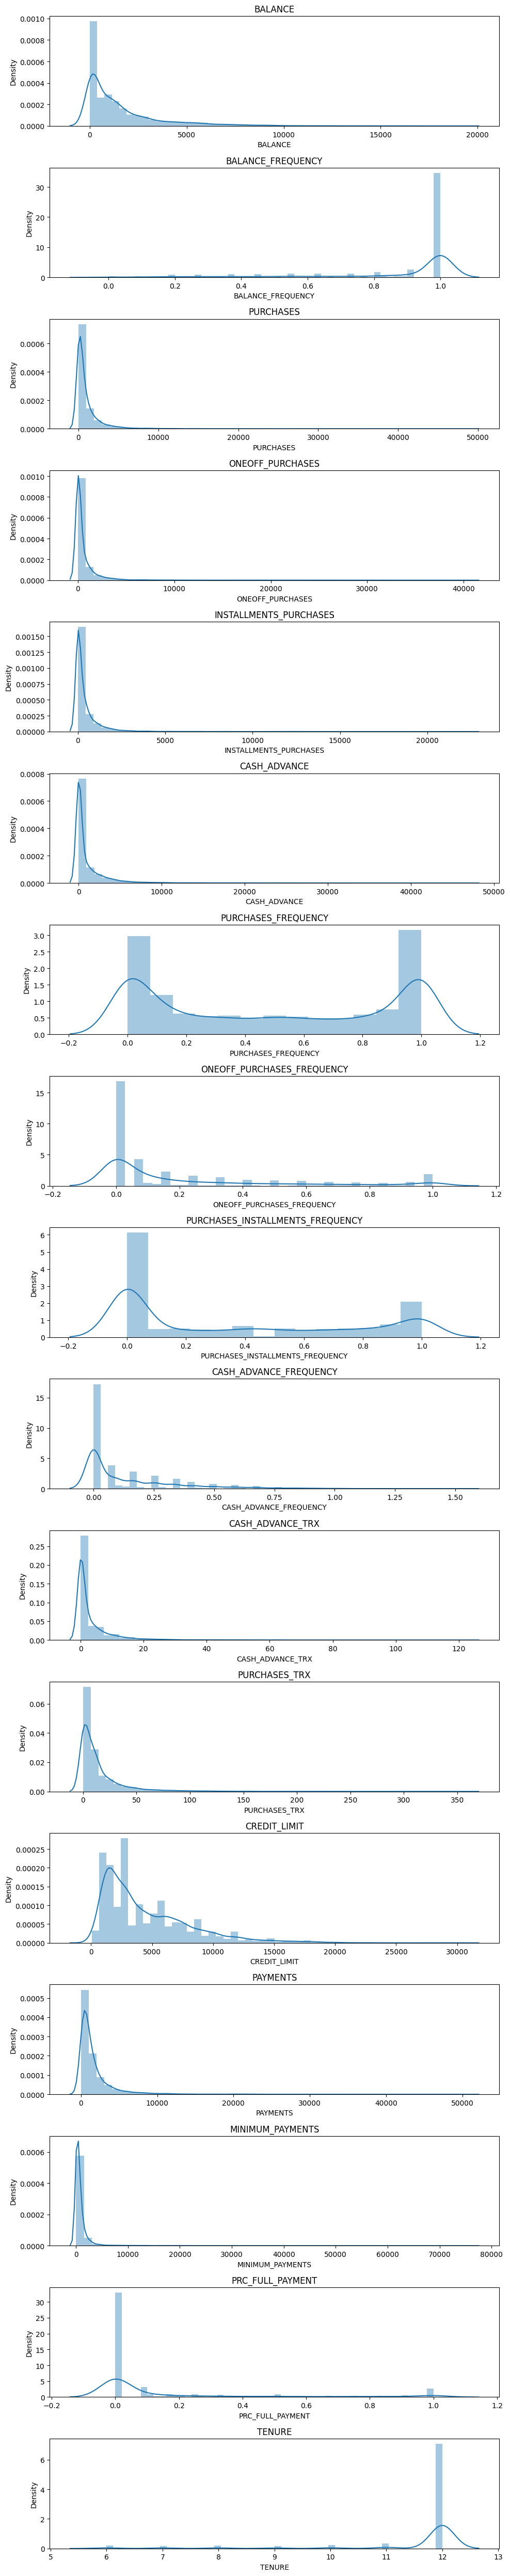

In [21]:
plt.figure(figsize=(10,50))
for i in range(len(creditcard_df.columns)):
    plt.subplot(17, 1, i + 1)
    sns.distplot(creditcard_df[creditcard_df.columns[i]], kde = True)
    plt.title(creditcard_df.columns[i])
plt.tight_layout();

In [22]:
correlations = creditcard_df.corr()

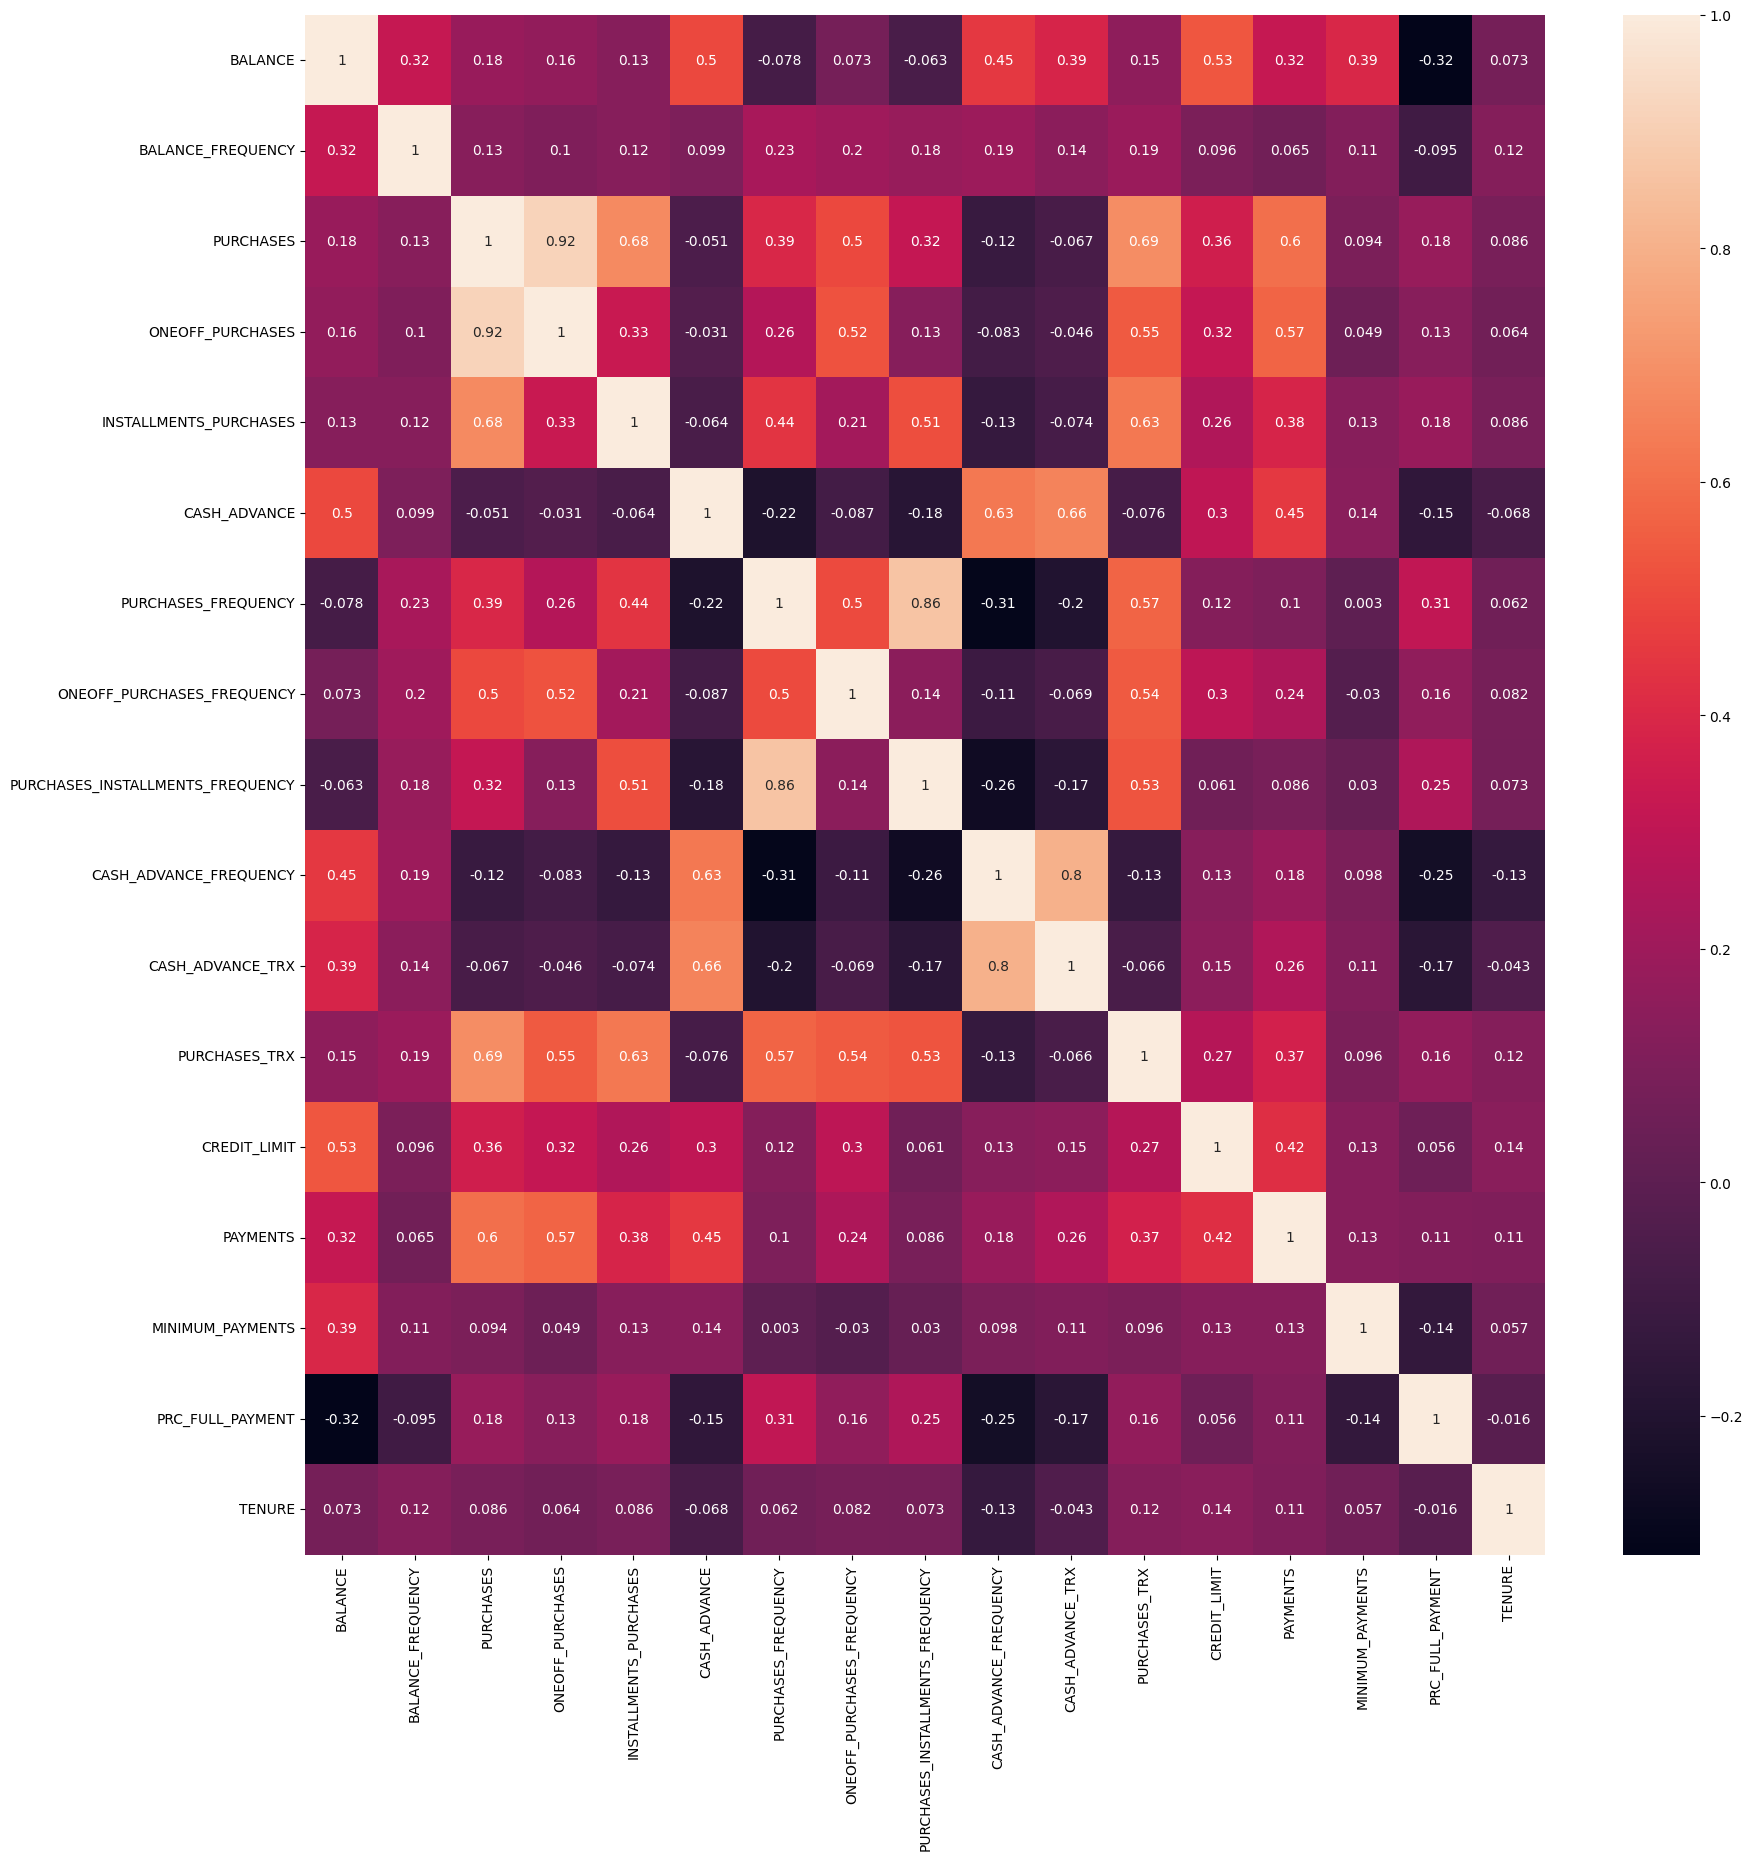

In [23]:
f, ax = plt.subplots(figsize=(20,20))
sns.heatmap(correlations, annot=True);

## Definição do número de clusters usando o Elbow Method

In [24]:
min(creditcard_df['BALANCE']), max(creditcard_df['BALANCE'])

(0.0, 19043.13856)

In [25]:
scaler = StandardScaler()
creditcard_df_scaled = scaler.fit_transform(creditcard_df)

In [26]:
type(creditcard_df_scaled), type(creditcard_df)

(numpy.ndarray, pandas.core.frame.DataFrame)

In [27]:
min(creditcard_df_scaled[0]), max(creditcard_df_scaled[0])

(np.float64(-0.9604333444542572), np.float64(0.36067954425377496))

In [28]:
creditcard_df_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

In [29]:
wcss_1 = []
for i in range(1, 20):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(creditcard_df_scaled)
    wcss_1.append(kmeans.inertia_)

In [30]:
print(wcss_1)

[152149.99999999983, 128957.90955338109, 112609.010712219, 99074.3941347625, 91502.98259428913, 84852.67262452352, 81779.60035676777, 76544.16655900326, 72729.30256881769, 67573.02350004358, 67275.44560032916, 61381.86245660548, 59179.80555220487, 57495.19286470207, 56842.48443282989, 55241.43079069222, 54649.1141296799, 52908.64078072844, 51161.22646708875]


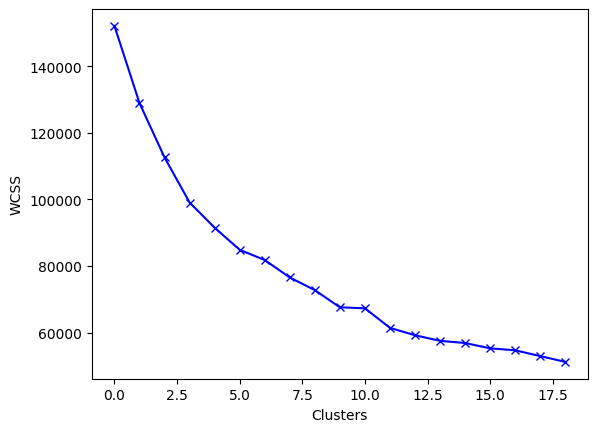

In [31]:
plt.plot(wcss_1, 'bx-')
plt.xlabel('Clusters')
plt.ylabel('WCSS');

## Agrupamento com k-means

In [32]:
kmeans = KMeans(n_clusters=8)
kmeans.fit(creditcard_df_scaled)
labels = kmeans.labels_

In [33]:
labels, len(labels)

(array([1, 6, 4, ..., 7, 7, 7], dtype=int32), 8950)

In [34]:
np.unique(labels, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([ 548, 2662,   30,  940, 2183, 1108,  857,  622]))

In [35]:
kmeans.cluster_centers_

array([[ 7.59505129e-01,  4.72979270e-01,  2.05942774e+00,
         1.72493416e+00,  1.70051698e+00, -2.12391799e-01,
         1.15511443e+00,  1.73269871e+00,  1.07657627e+00,
        -3.09840322e-01, -2.27119199e-01,  2.43553704e+00,
         1.16134302e+00,  1.13598297e+00,  3.27882124e-01,
         2.21366145e-01,  3.17045022e-01],
       [ 2.36202380e-02,  4.02177300e-01, -3.62296646e-01,
        -2.41775459e-01, -4.12334345e-01, -7.71692790e-02,
        -8.93434697e-01, -4.03374203e-01, -7.93168339e-01,
         1.32602554e-01, -1.08554510e-02, -4.93190606e-01,
        -2.94021912e-01, -2.44101046e-01, -5.19811746e-03,
        -4.52932396e-01,  2.70538838e-01],
       [ 1.92305052e+00,  3.37716867e-01,  1.12120418e+01,
         1.06003671e+01,  7.03311838e+00,  4.19625127e-01,
         1.04698328e+00,  1.91550149e+00,  9.81333653e-01,
        -2.58911831e-01,  6.12285458e-02,  5.36243850e+00,
         3.04406408e+00,  8.09897492e+00,  1.12031761e+00,
         1.11013157e+00,  3.1

In [36]:
cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [creditcard_df.columns])
cluster_centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,0.759505,0.472979,2.059428,1.724934,1.700517,-0.212392,1.155114,1.732699,1.076576,-0.309840,-0.227119,2.435537,1.161343,1.135983,0.327882,0.221366,0.317045
1,0.023620,0.402177,-0.362297,-0.241775,-0.412334,-0.077169,-0.893435,-0.403374,-0.793168,0.132603,-0.010855,-0.493191,-0.294022,-0.244101,-0.005198,-0.452932,0.270539
2,1.923051,0.337717,11.212042,10.600367,7.033118,0.419625,1.046983,1.915501,0.981334,-0.258912,0.061229,5.362438,3.044064,8.098975,1.120318,1.110132,0.310863
3,-0.690548,0.117532,0.139731,0.010049,0.311464,-0.449105,0.900160,0.361379,0.720976,-0.643356,-0.458610,0.230892,0.148021,-0.109290,-0.292342,2.168094,0.189768
4,-0.159305,0.399182,0.039360,-0.049610,0.184127,-0.324950,0.927924,0.250308,0.834566,-0.393406,-0.315310,0.246099,-0.179761,-0.161632,0.009608,-0.334905,0.288145
5,-0.699543,-2.207062,-0.323351,-0.242780,-0.318385,-0.313210,-0.582892,-0.456858,-0.455135,-0.510691,-0.368416,-0.429019,-0.203005,-0.207261,-0.253225,0.092261,0.196799
6,1.683074,0.394004,-0.211558,-0.145259,-0.233419,2.033770,-0.456976,-0.170191,-0.418843,1.936118,1.957589,-0.259336,1.030898,0.832432,0.540238,-0.392169,0.067712
7,-0.332825,-0.344129,-0.287118,-0.205018,-0.301852,0.072498,-0.196537,-0.269970,-0.234654,0.313908,0.002881,-0.385982,-0.563404,-0.392199,-0.205867,-0.035486,-3.194122


In [37]:
cluster_centers = scaler.inverse_transform(cluster_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [creditcard_df.columns])
cluster_centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3145.320643,0.989315,5403.203942,3455.474781,1948.824051,533.475588,0.953954,0.719355,0.792296,0.073142,1.698905,75.248175,8719.890511,5021.703229,1628.322002,0.218460,11.941606
1,1613.638359,0.972543,229.152465,191.139628,38.198812,817.043530,0.131772,0.082123,0.049212,0.161679,3.174746,2.450958,3424.677440,1026.495241,852.092549,0.021240,11.879369
2,5567.142164,0.957273,24957.905000,18186.875667,6771.029333,1858.844605,0.910556,0.773889,0.754444,0.083333,3.666667,148.000000,15570.000000,25178.882690,3475.059479,0.478409,11.933333
3,127.156652,0.905113,1301.741713,609.116117,692.720255,37.077642,0.851628,0.310264,0.650971,0.006402,0.119149,20.448936,5033.010155,1416.759496,182.915211,0.787845,11.771277
4,1232.895332,0.971833,1087.297866,510.095160,577.570975,297.435927,0.862771,0.277129,0.696115,0.056420,1.097070,20.826923,3840.404272,1265.235431,886.597170,0.055761,11.902930
5,108.434832,0.354438,312.361092,189.472915,123.156047,322.055321,0.256408,0.066168,0.183555,0.032950,0.734657,4.046029,3755.834336,1133.144695,274.076271,0.180700,11.780686
6,5067.651437,0.970607,551.207258,351.336488,199.989405,5243.782184,0.306944,0.151686,0.197978,0.522581,16.607935,8.263711,8245.279516,4142.952620,2123.209371,0.039012,11.607935
7,871.727207,0.795750,389.773601,252.149727,138.106190,1130.903517,0.411471,0.121920,0.271180,0.197960,3.268489,5.115756,2444.556993,597.766825,384.441450,0.143336,7.242765


In [38]:
labels, len(labels)

(array([1, 6, 4, ..., 7, 7, 7], dtype=int32), 8950)

In [39]:
creditcard_df_cluster = pd.concat([creditcard_df, pd.DataFrame({'cluster': labels})], axis = 1)
creditcard_df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,6
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,4
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


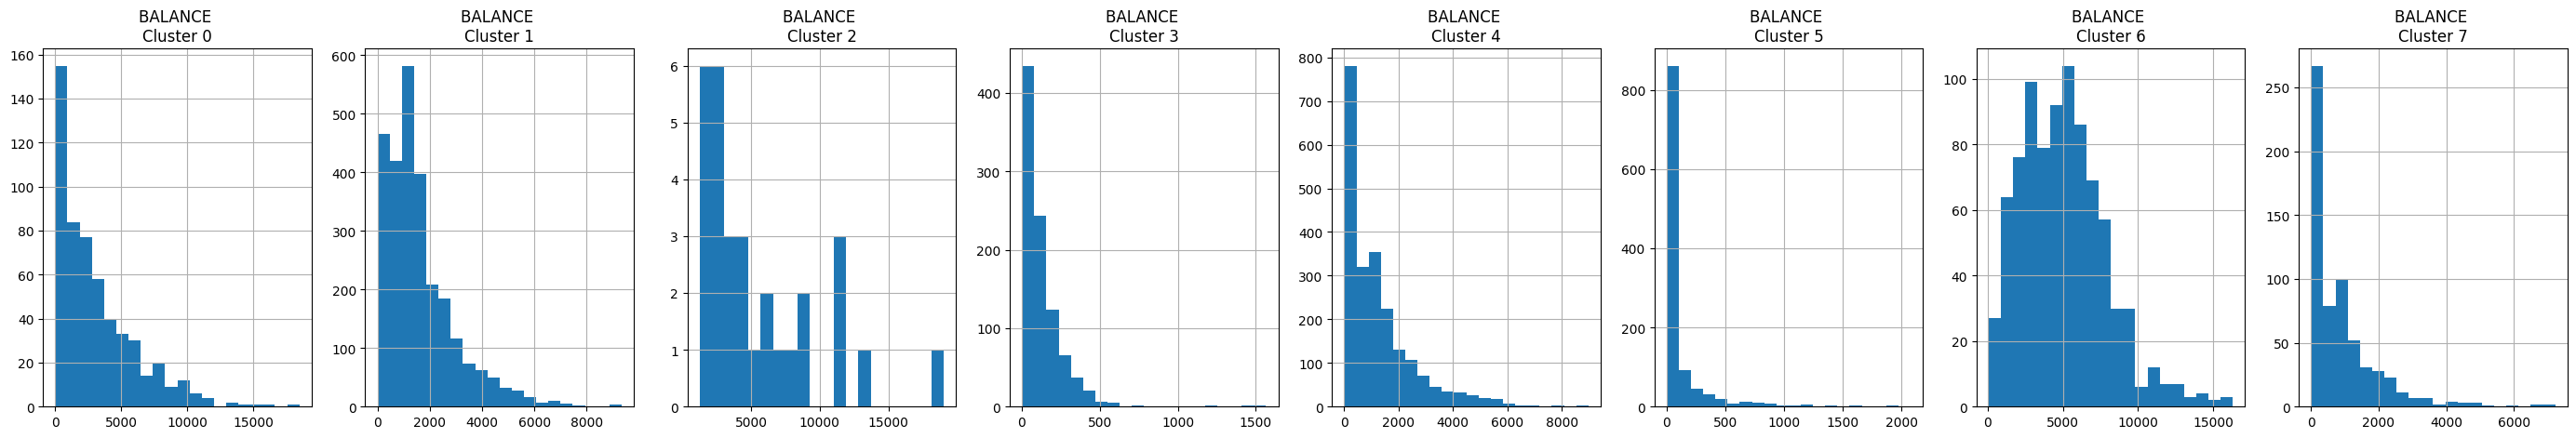

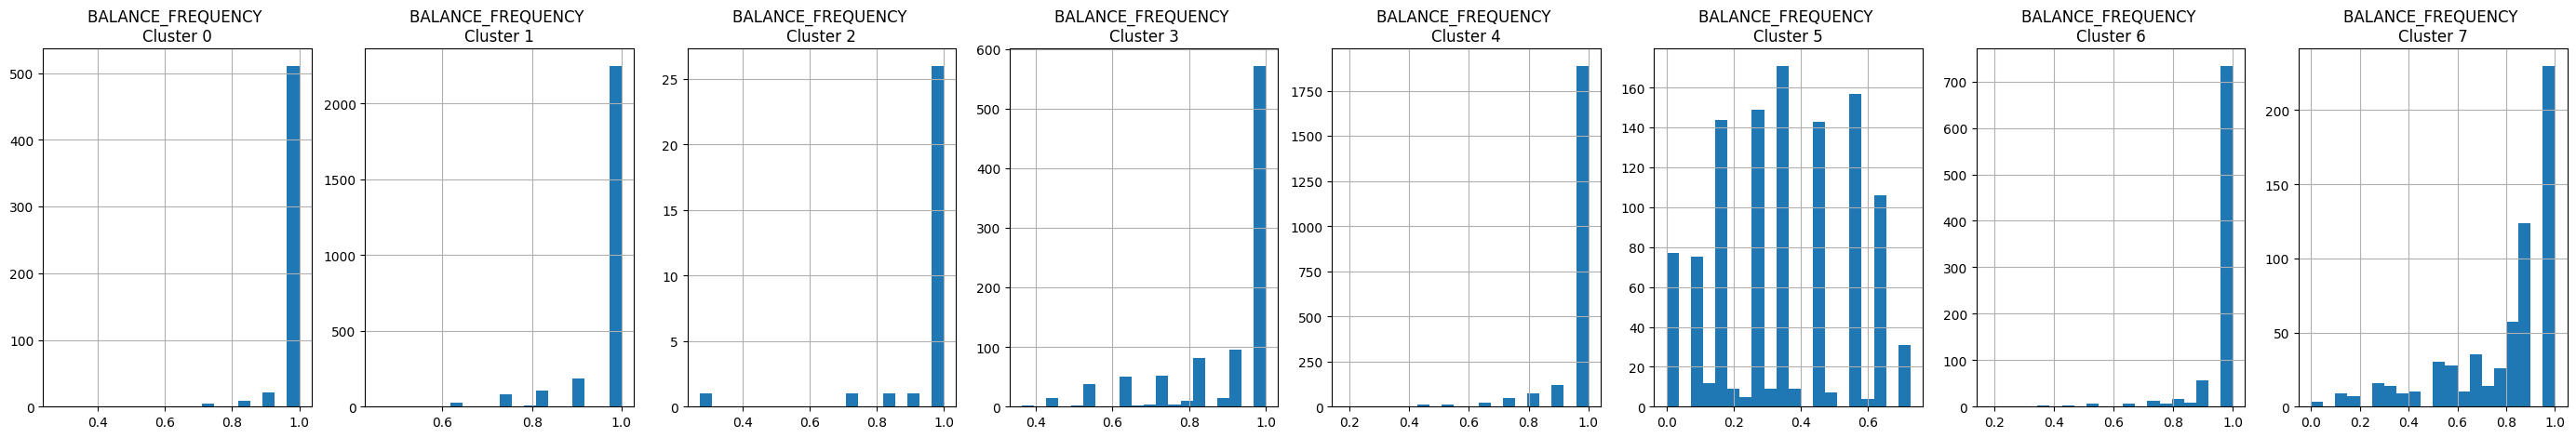

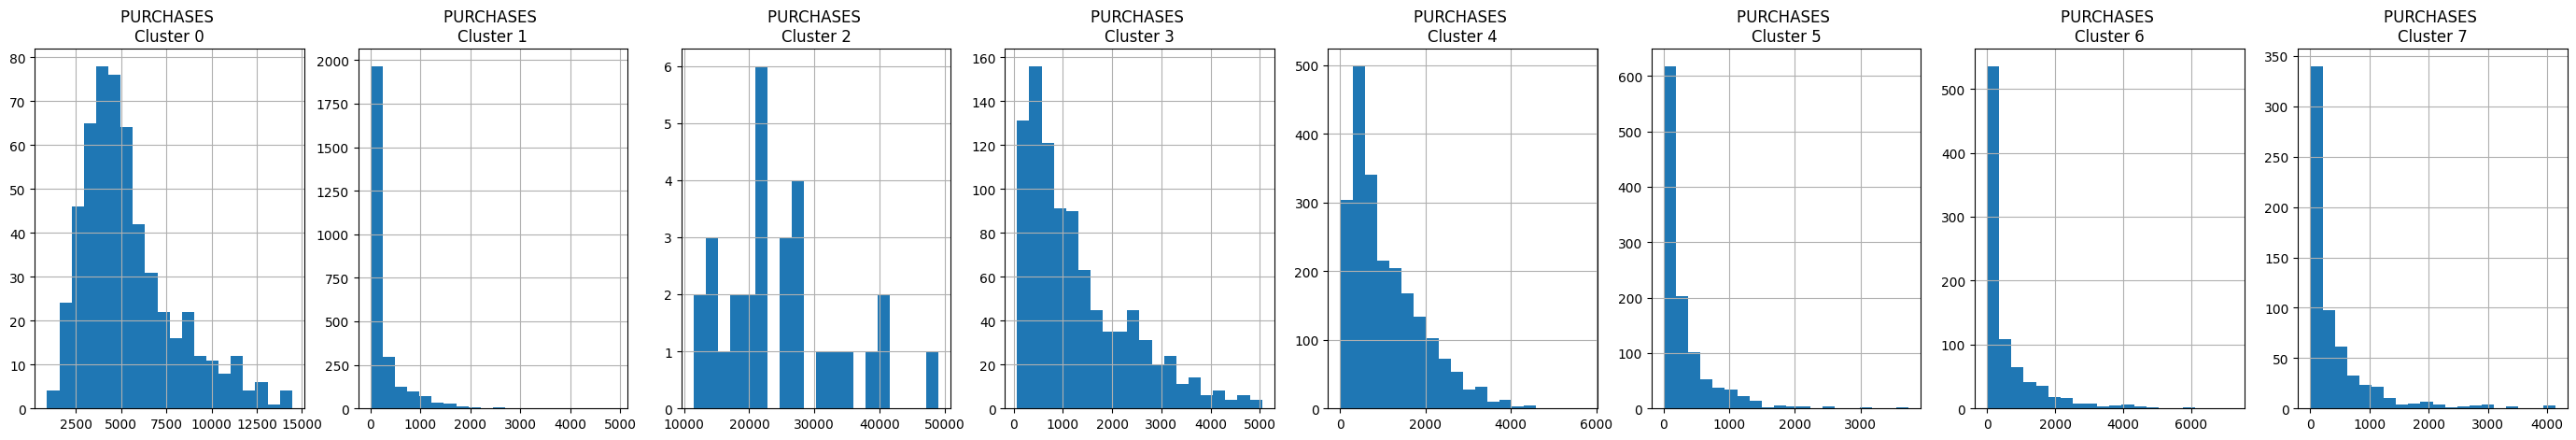

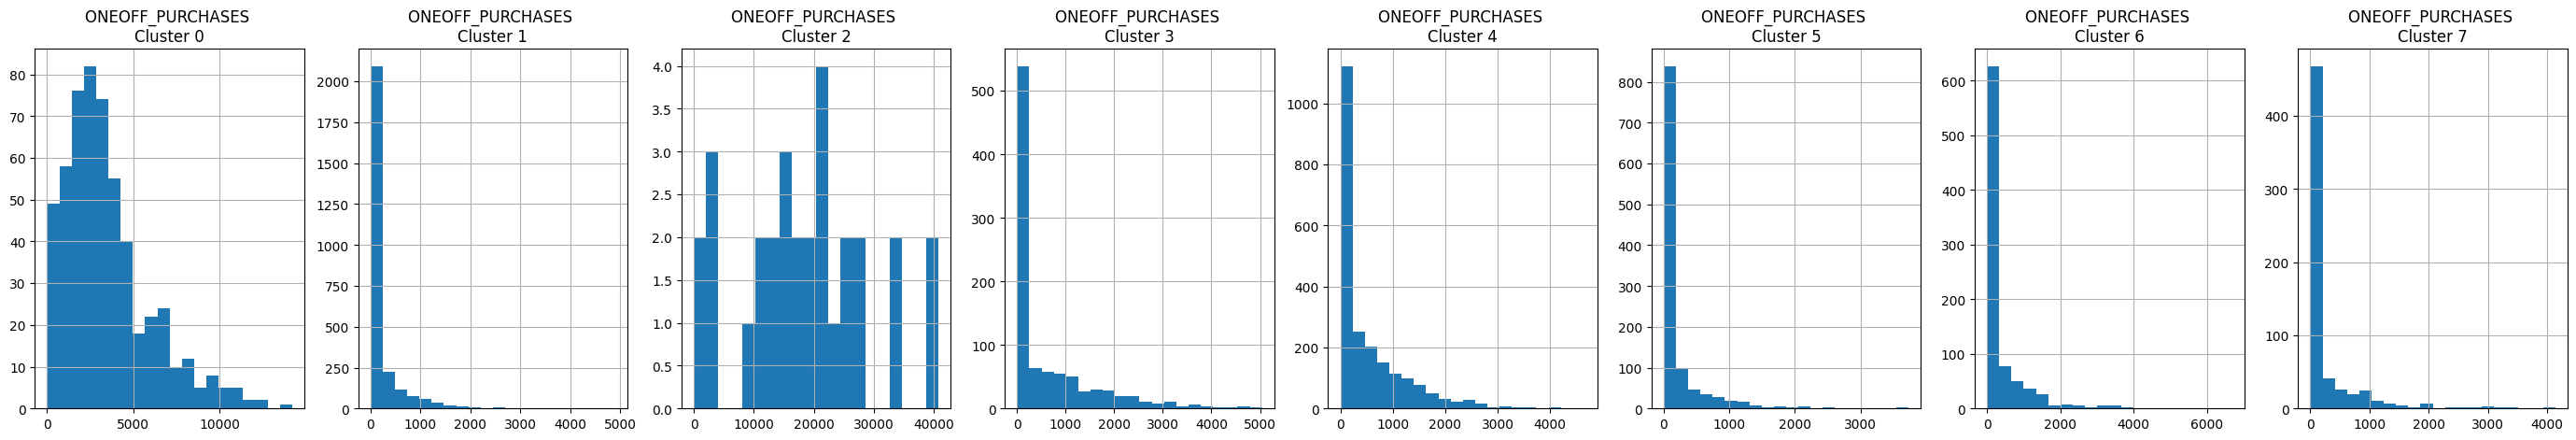

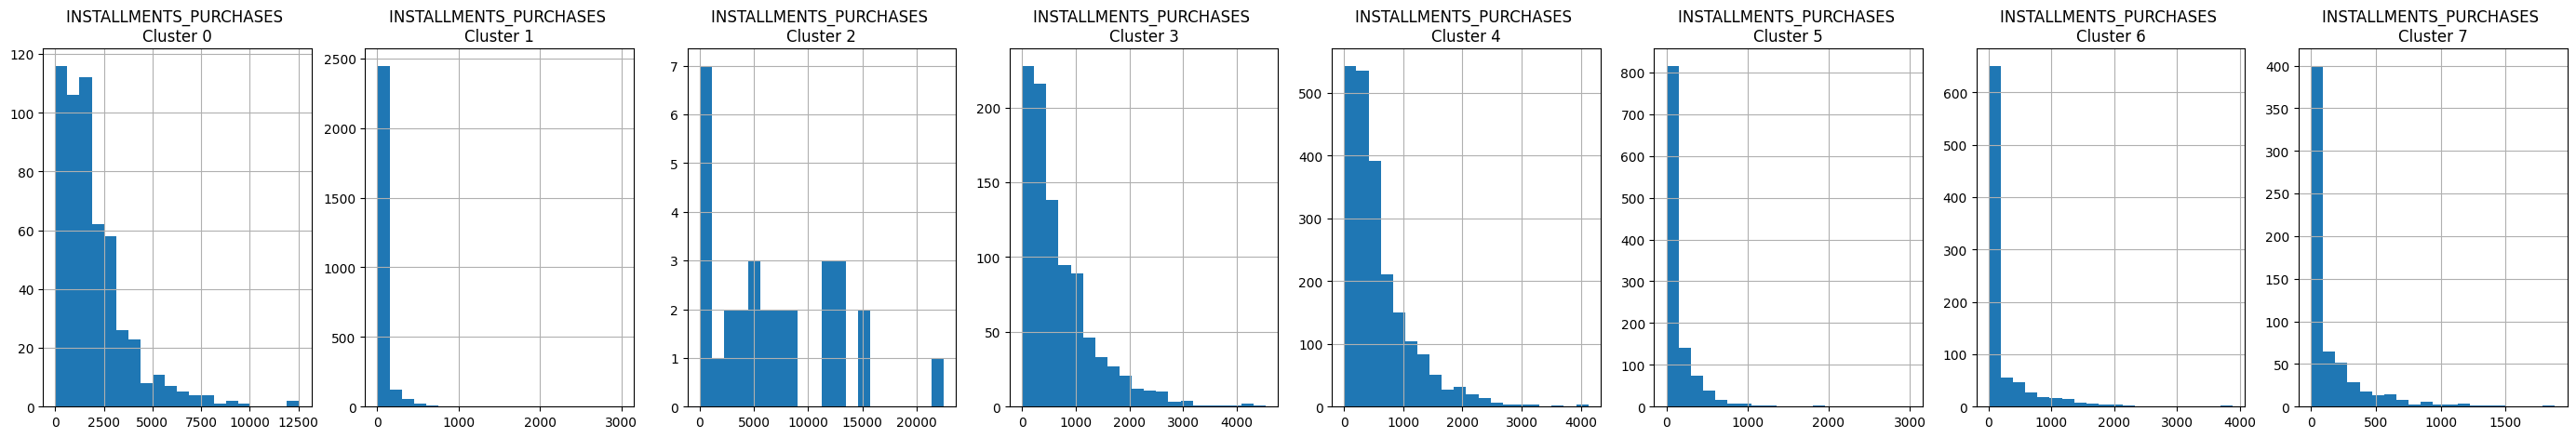

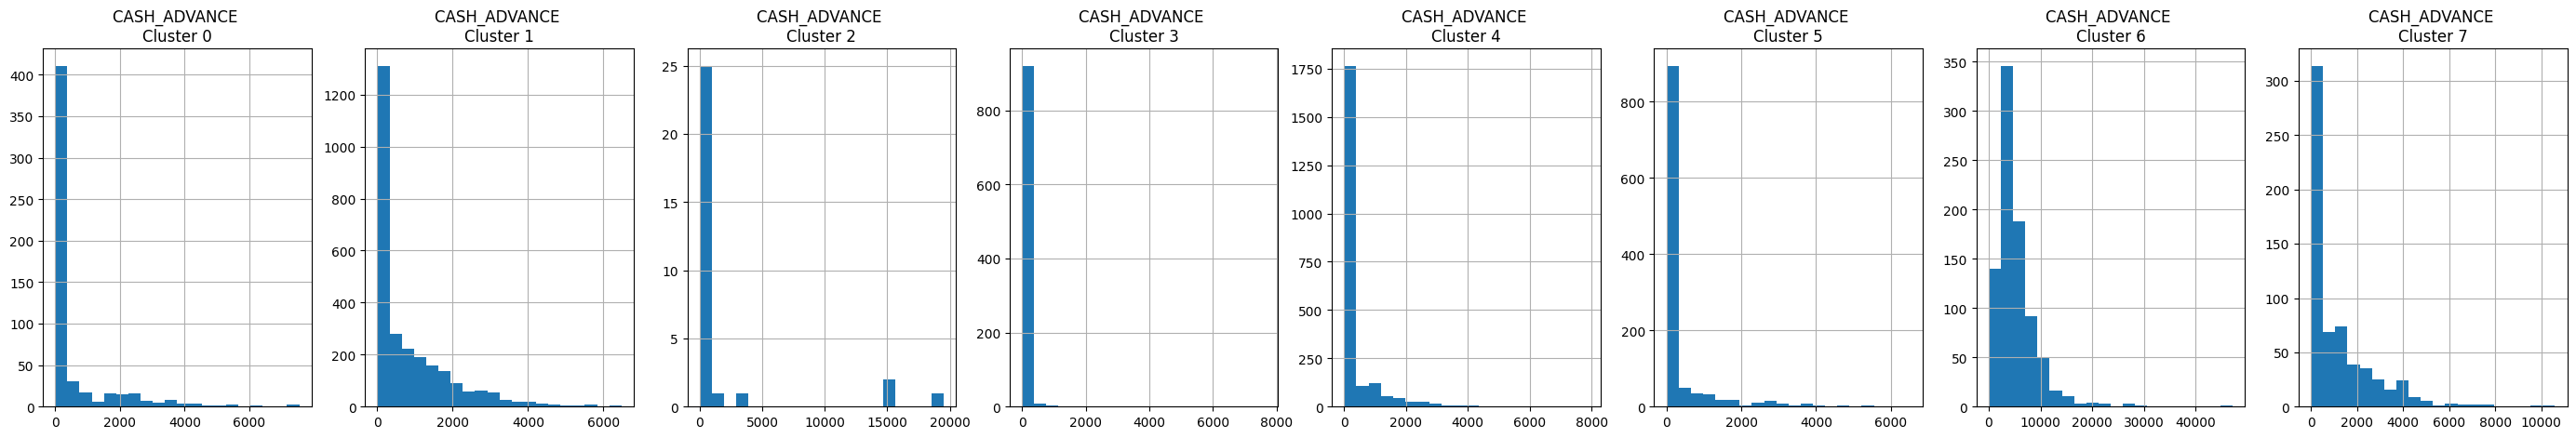

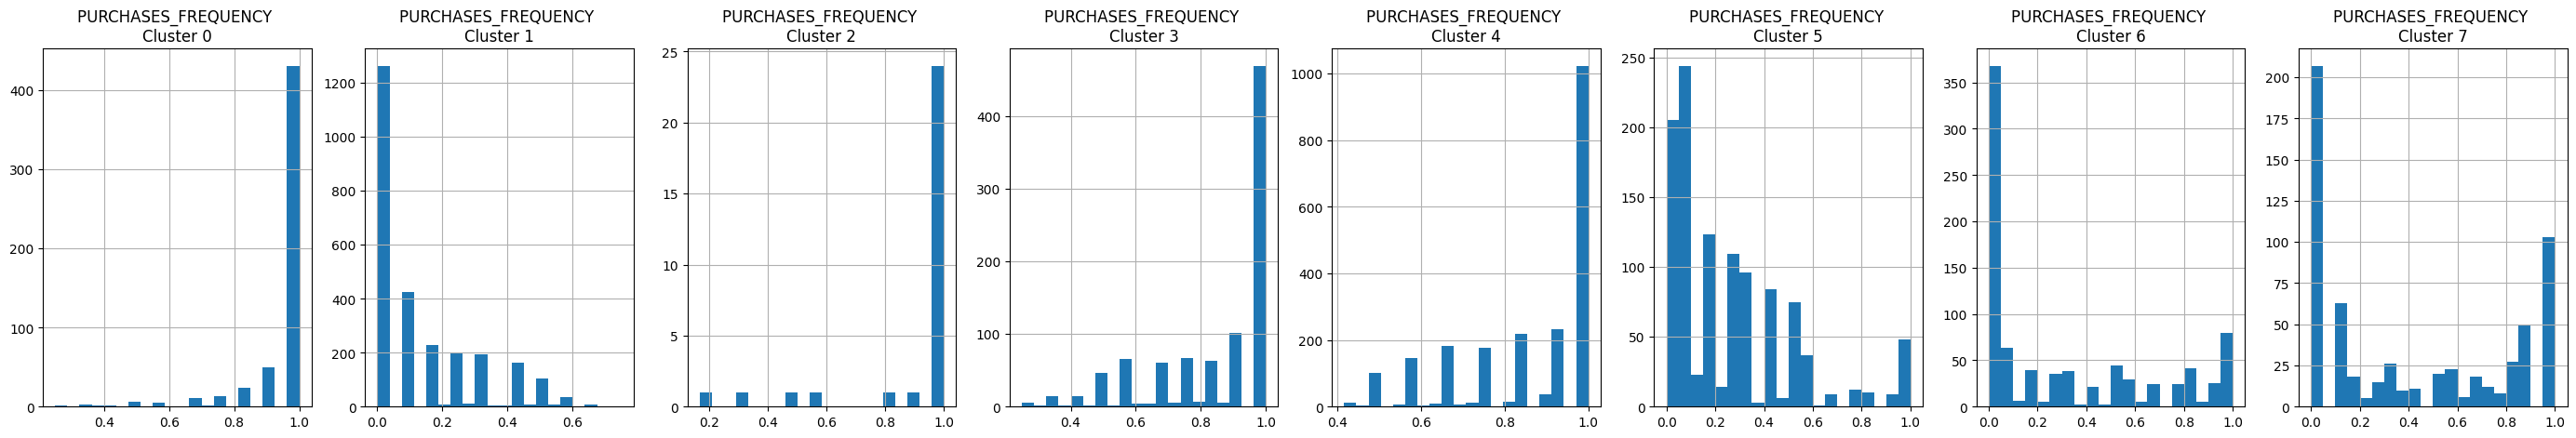

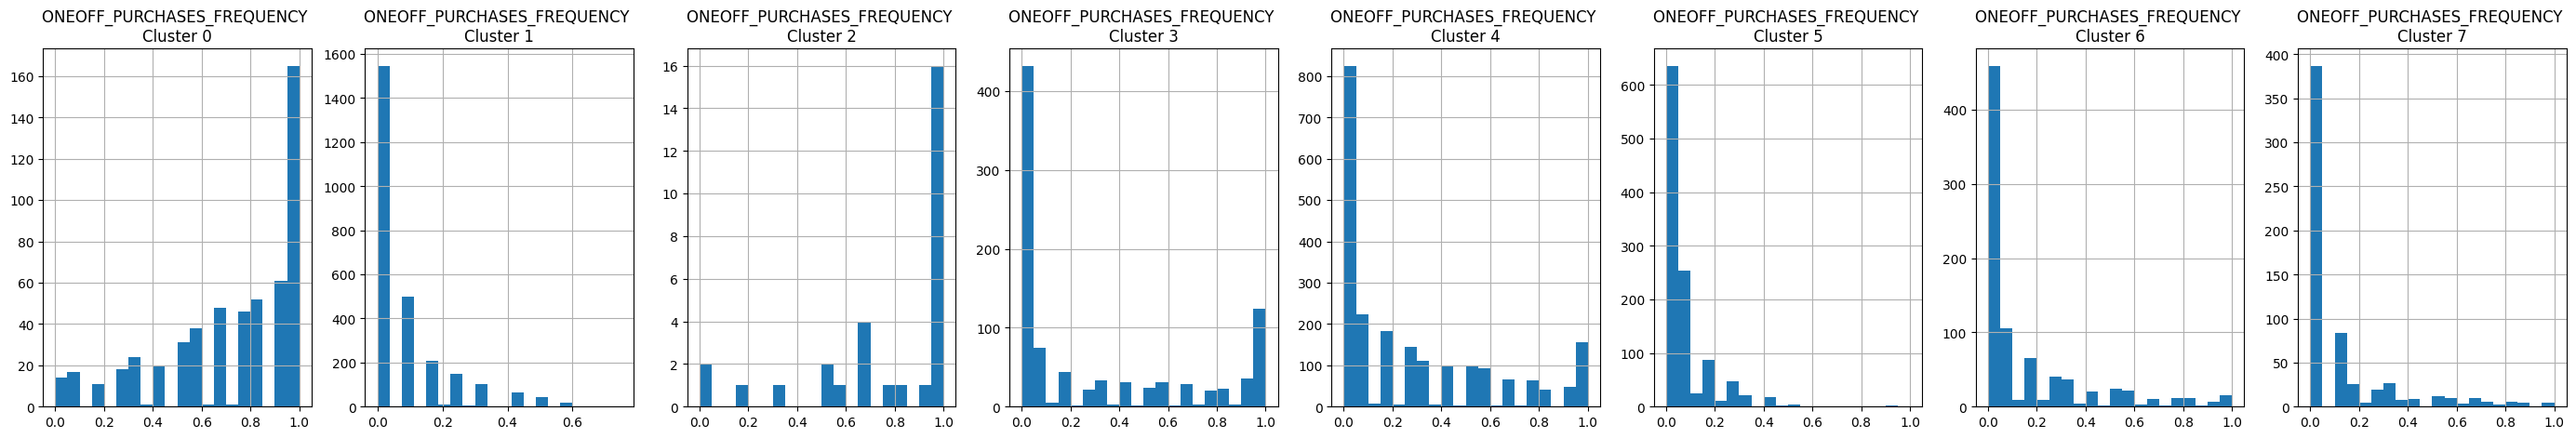

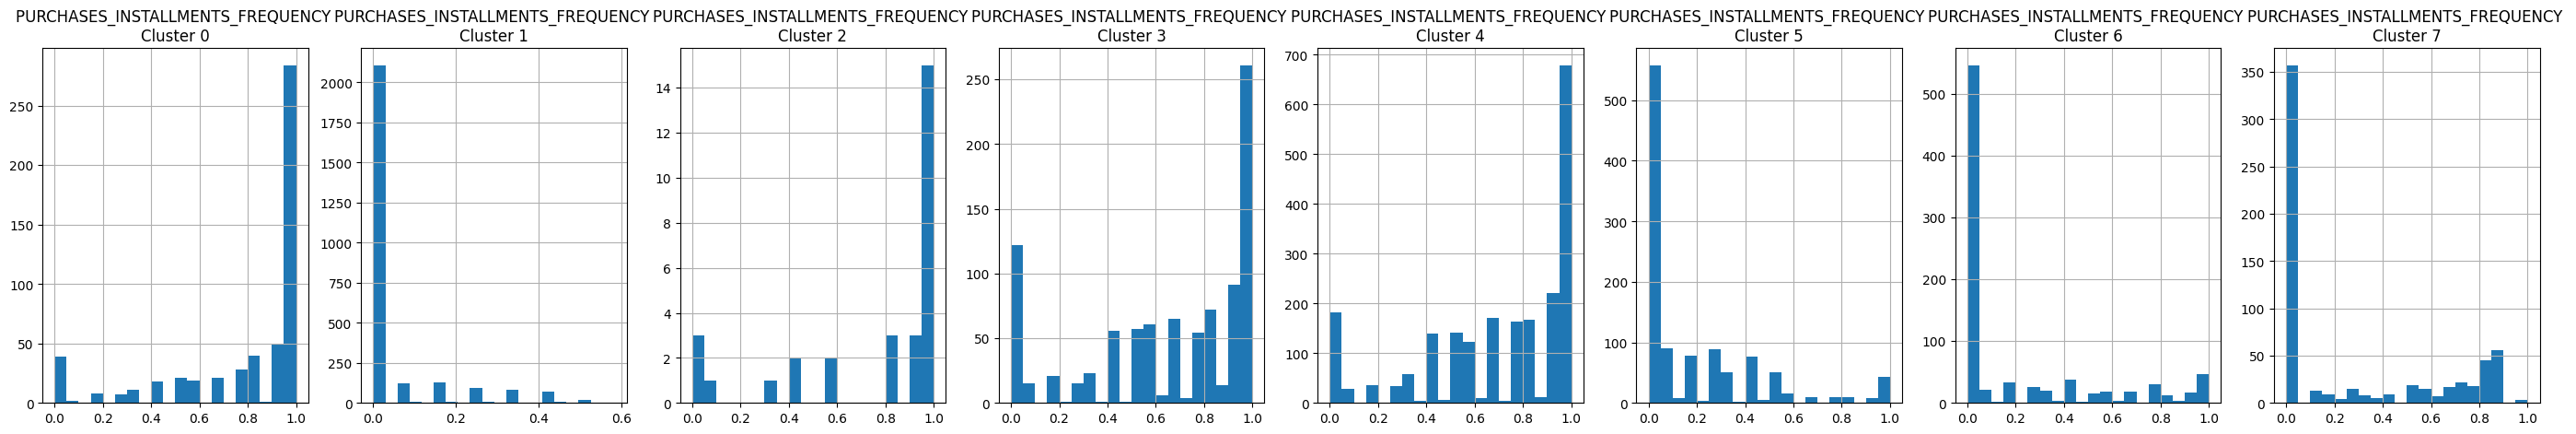

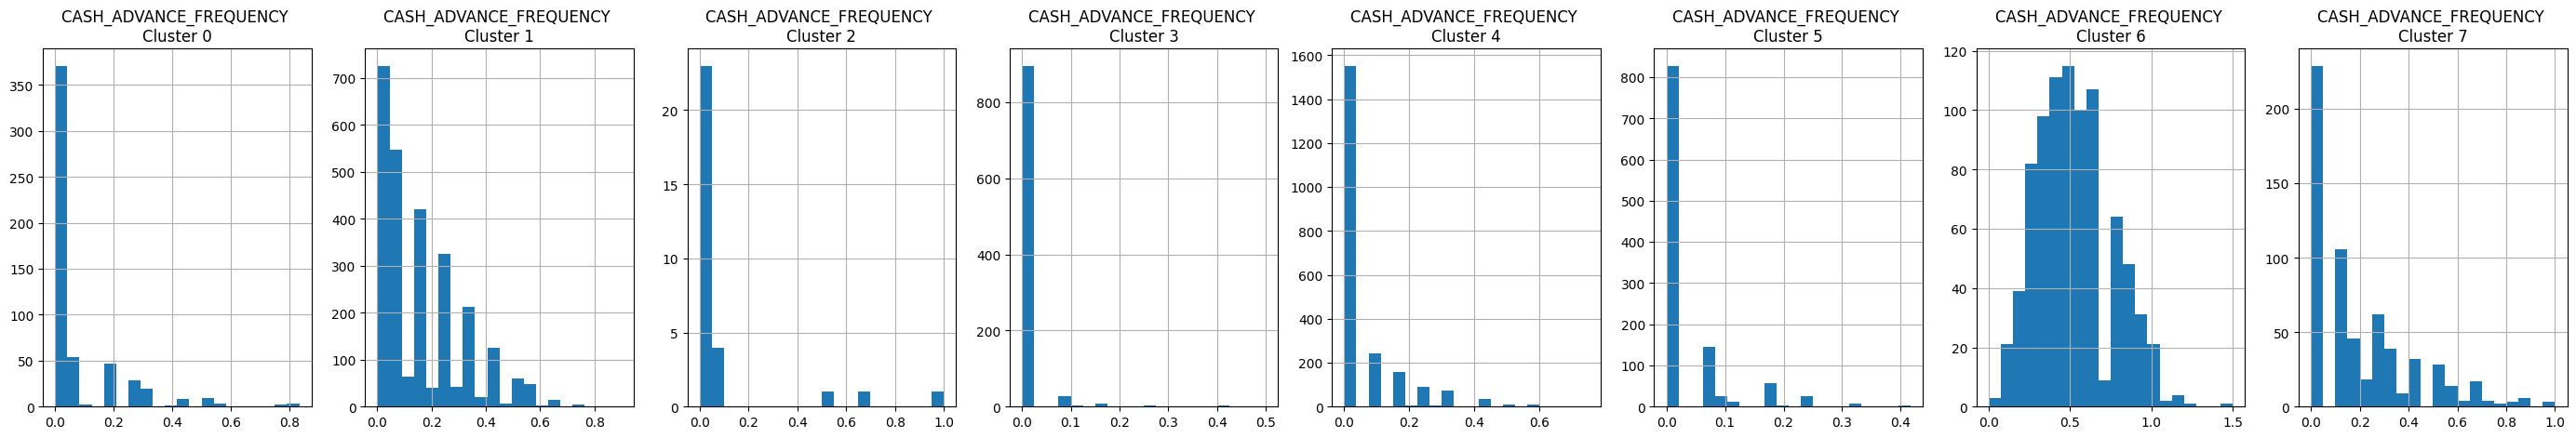

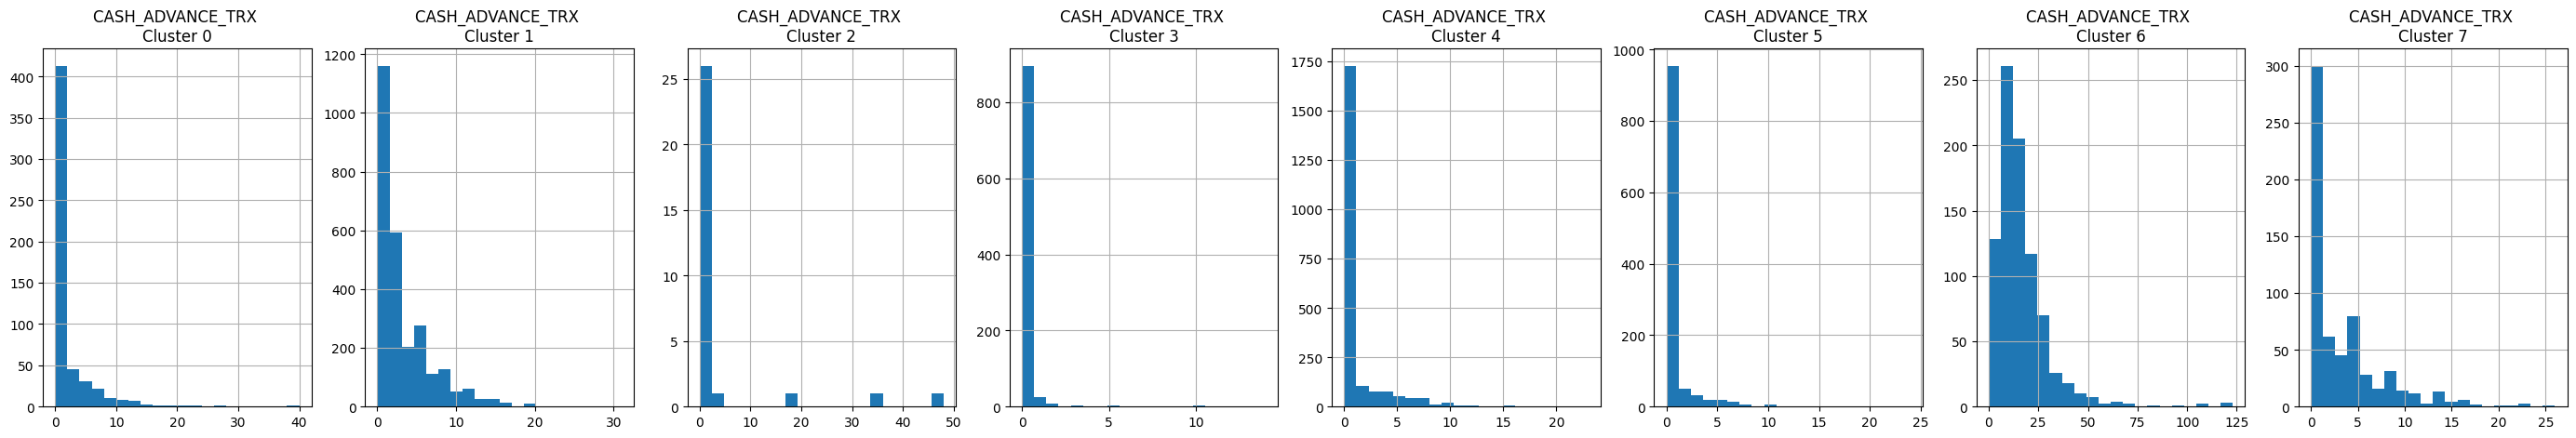

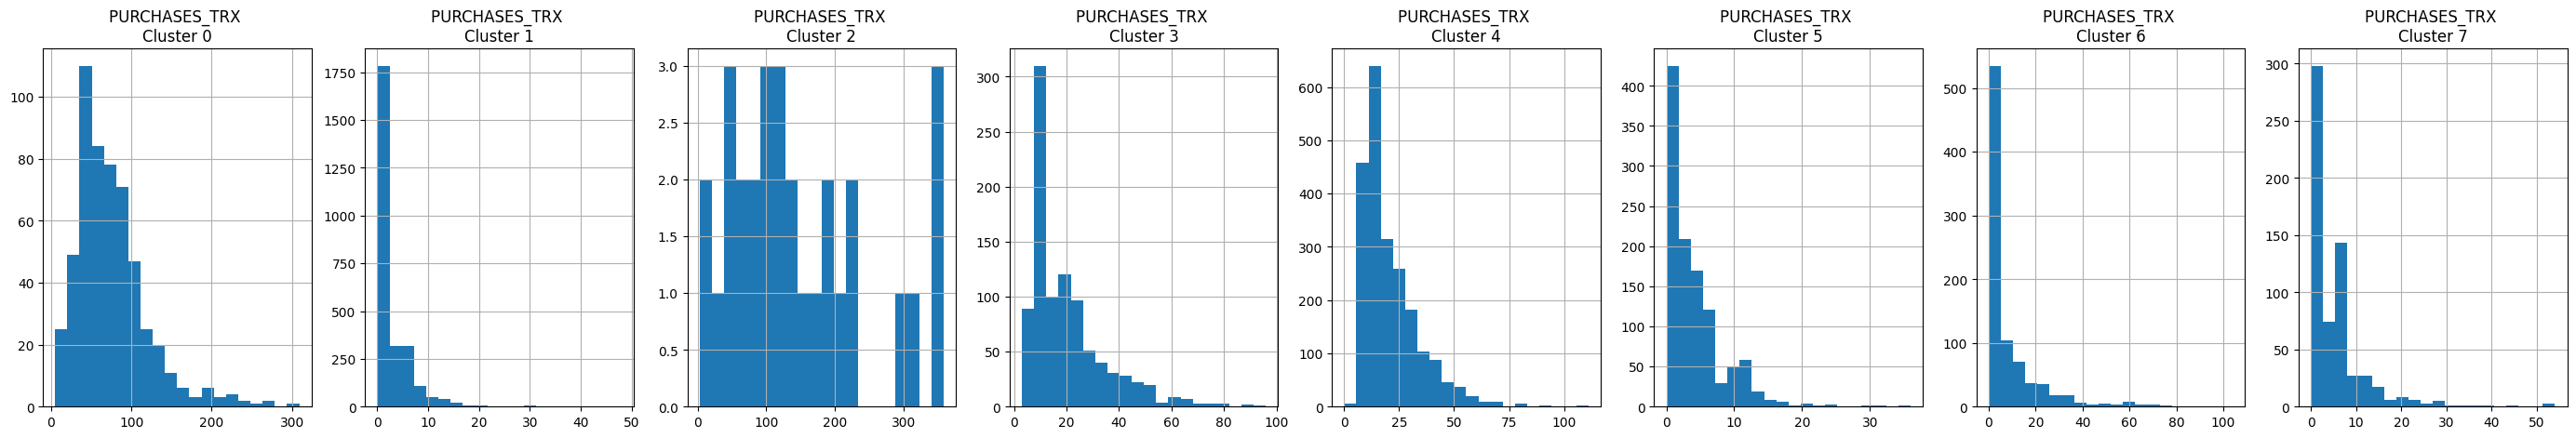

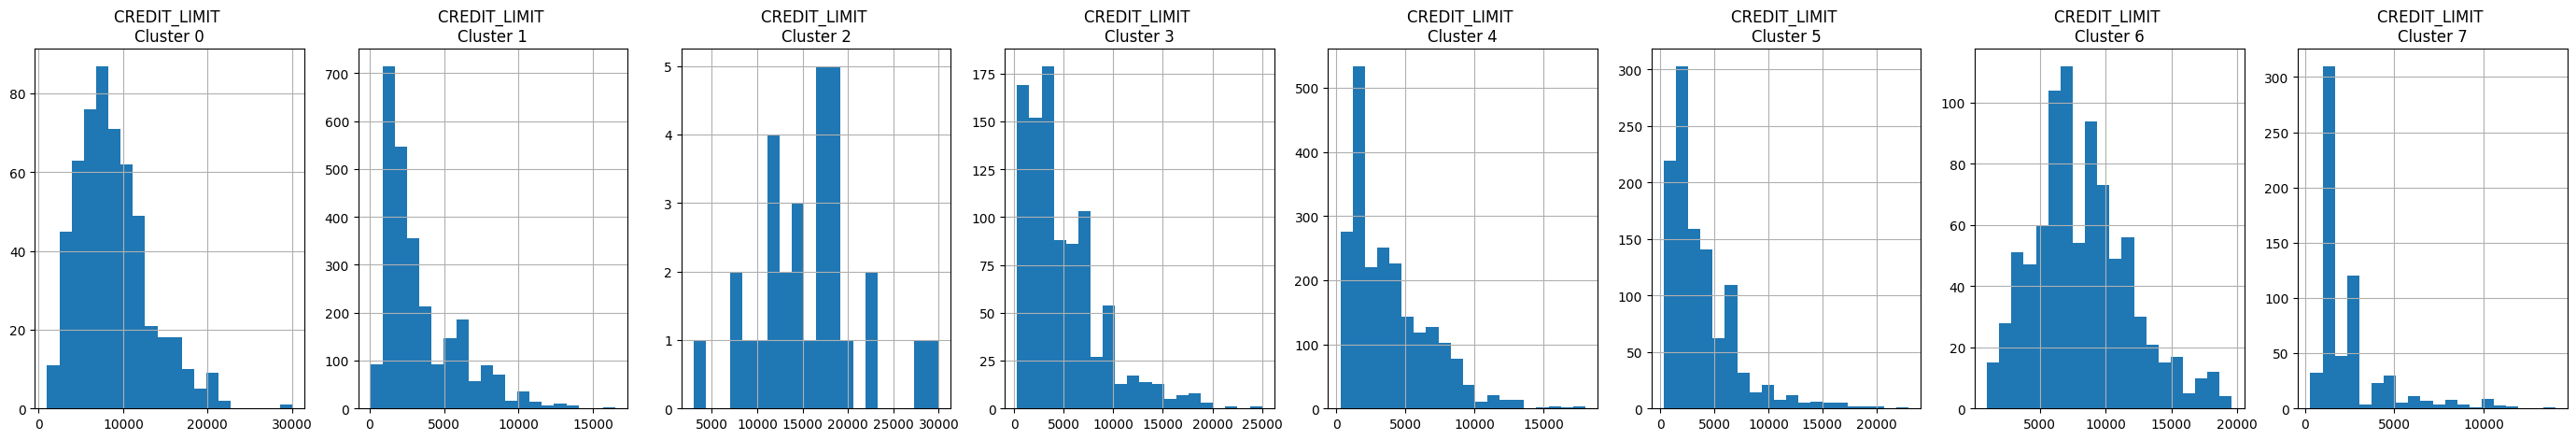

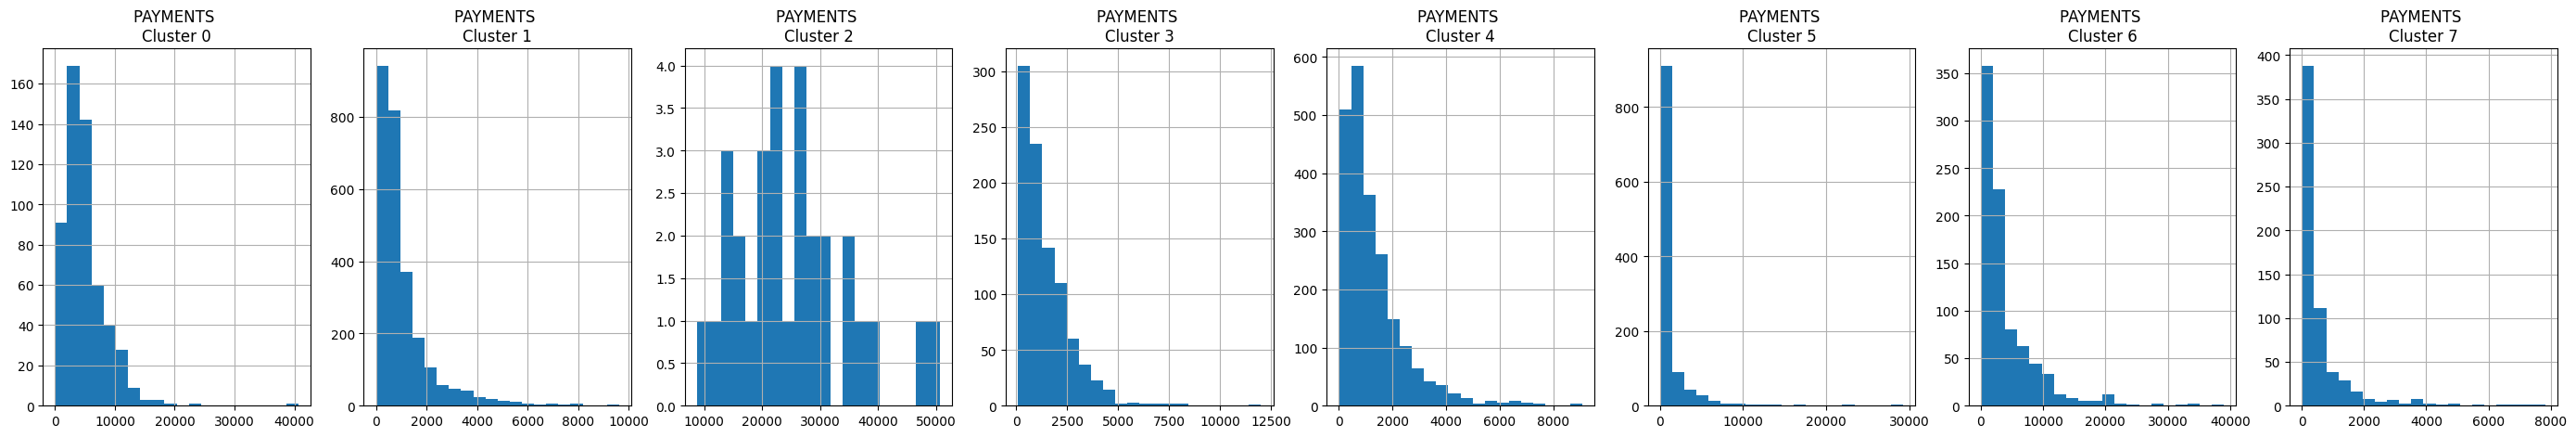

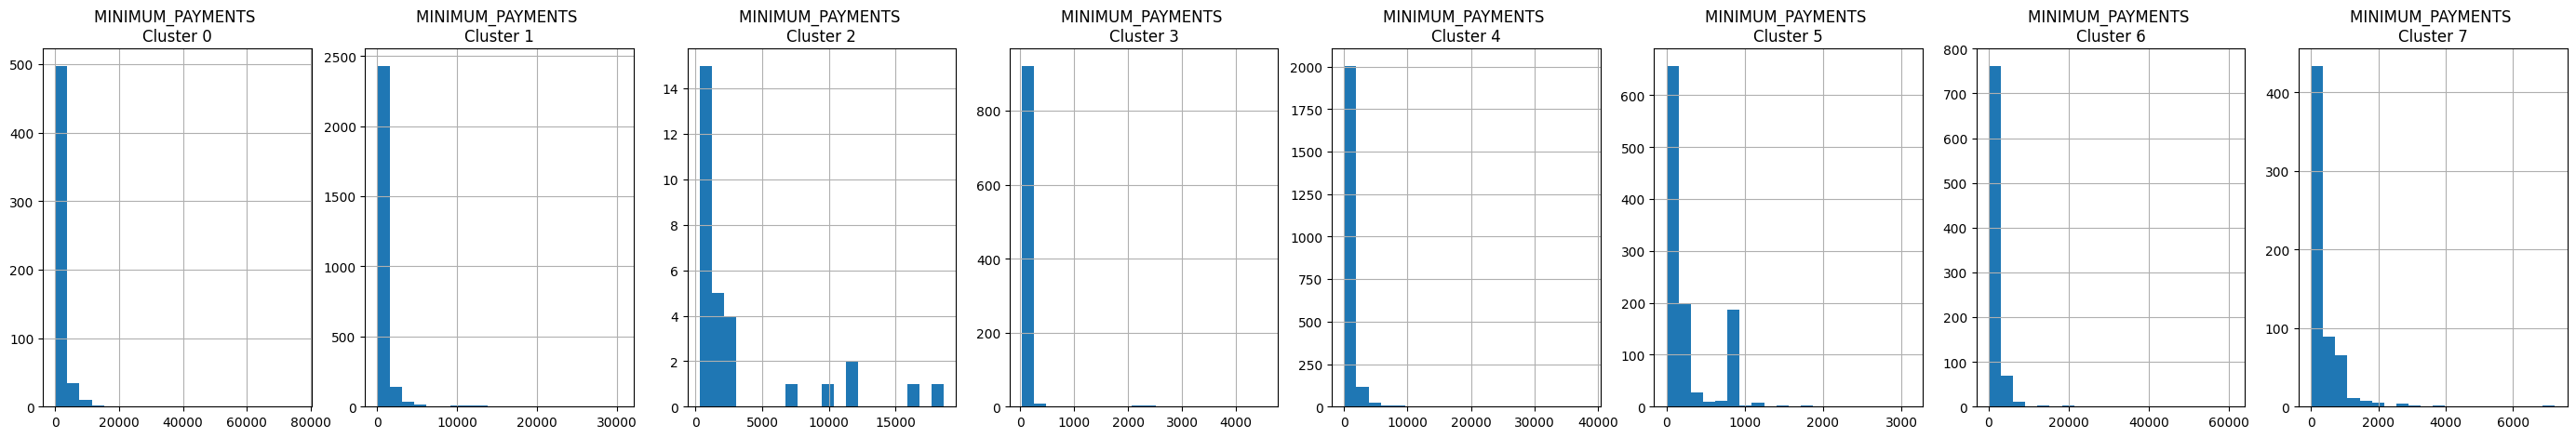

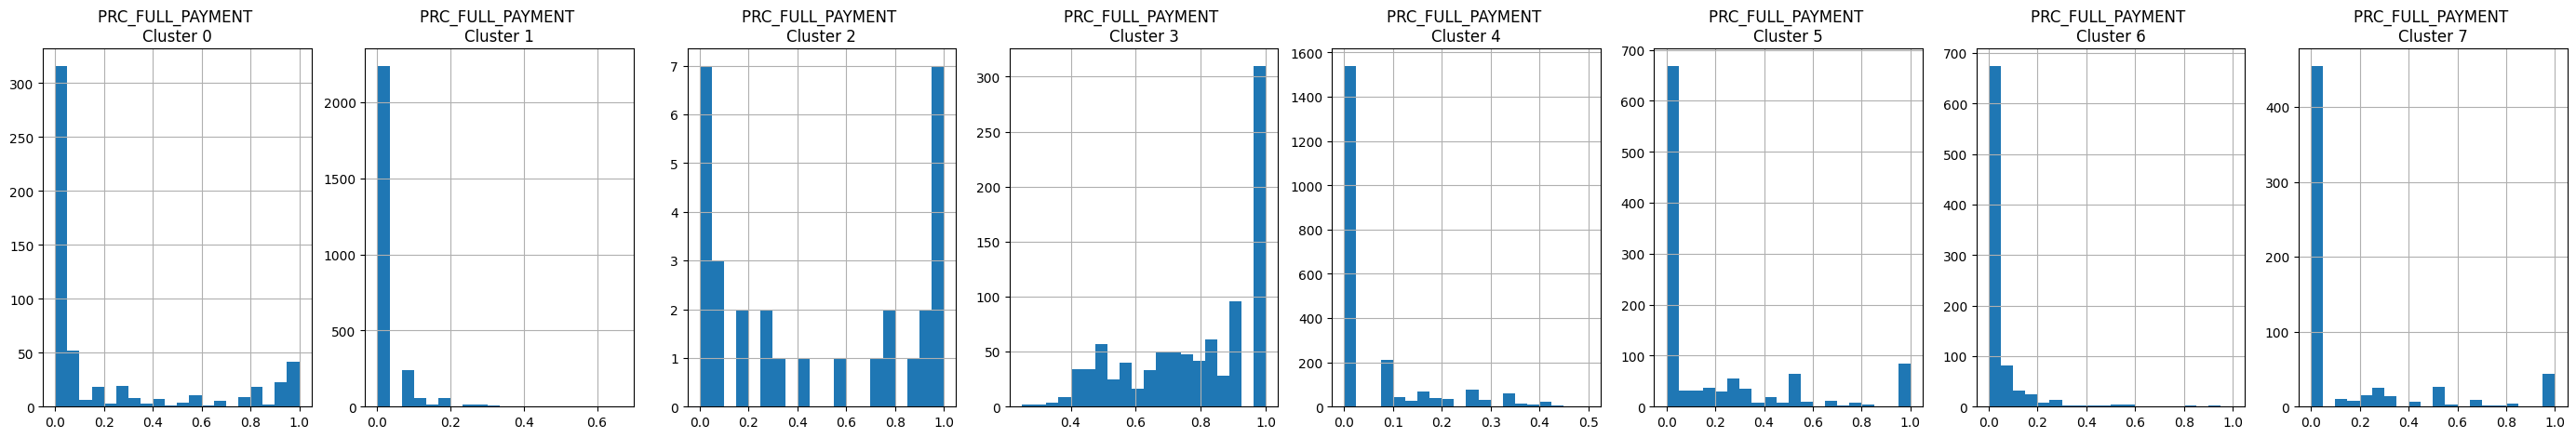

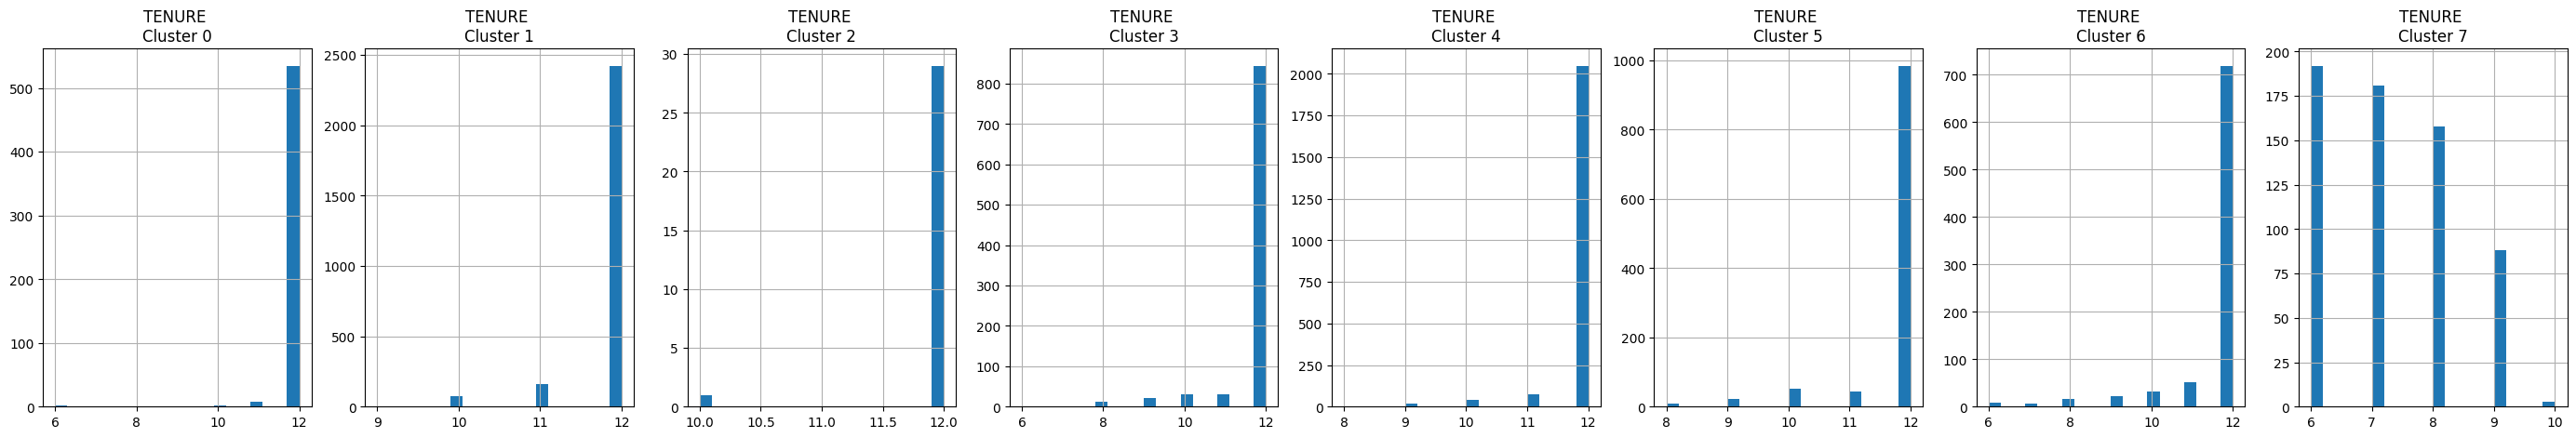

In [40]:
for i in creditcard_df.columns:
    plt.figure(figsize=(35,5))
    for j in range(8):
        plt.subplot(1, 8, j+1)
        cluster = creditcard_df_cluster[creditcard_df_cluster['cluster'] == j]
        cluster[i].hist(bins =20)
        plt.title('{} \nCluster {}'.format(i, j))
    plt.show()

In [41]:
credit_ordered = creditcard_df_cluster.sort_values(by = 'cluster')
credit_ordered.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
616,837.950585,1.0,8273.18,2904.89,5368.29,0.000000,1.000000,1.000000,1.000000,0.0,0,53,7000.0,7883.621179,208.069929,1.000000,12,0
619,3774.063585,1.0,7680.08,5050.97,2629.11,0.000000,1.000000,0.583333,1.000000,0.0,0,64,11500.0,2529.085319,1256.196236,0.000000,12,0
620,1088.031913,1.0,9734.63,3756.01,5978.62,0.000000,1.000000,1.000000,1.000000,0.0,0,194,8500.0,8571.945329,204.762568,0.083333,12,0
622,5248.392421,1.0,8403.17,7469.70,933.47,3141.100688,0.833333,0.666667,0.750000,0.5,12,117,13000.0,8495.972927,1183.069705,0.250000,12,0
624,3123.339488,1.0,11202.09,10929.53,272.56,0.000000,1.000000,1.000000,0.583333,0.0,0,100,7500.0,8317.163283,887.495688,0.083333,12,0


In [42]:
credit_ordered.tail()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
8137,31.997904,0.333333,0.00,0.0,0.00,136.755929,0.000000,0.000000,0.000000,0.166667,1,0,500.0,0.000000,864.206542,0.0,6,7
8154,1276.491537,0.833333,65.80,65.8,0.00,4422.783845,0.166667,0.166667,0.000000,0.500000,6,2,2500.0,3533.025919,474.861178,0.0,6,7
4676,2042.585017,0.857143,498.96,0.0,498.96,2364.540395,0.857143,0.000000,0.714286,0.285714,5,9,2500.0,414.718951,1517.202791,0.0,7,7
3625,11.799054,0.500000,77.36,0.0,77.36,0.000000,0.500000,0.000000,0.375000,0.000000,0,4,1200.0,103.635381,117.664686,1.0,8,7
8101,2934.090889,0.875000,0.00,0.0,0.00,2710.056224,0.000000,0.000000,0.000000,0.250000,2,0,3000.0,428.467582,694.749539,0.0,8,7


In [43]:
credit_ordered.to_csv('cluster.csv')

## Aplicação de PCA (principal component analysis) e visualização dos resultados

In [44]:
pca = PCA(n_components=2)
principal_comp = pca.fit_transform(creditcard_df_scaled)
principal_comp

array([[-1.68222026, -1.07645061],
       [-1.1382949 ,  2.50647666],
       [ 0.96968401, -0.3835203 ],
       ...,
       [-0.92620364, -1.8107856 ],
       [-2.33655167, -0.65796601],
       [-0.55642216, -0.40046712]])

In [45]:
pca_df = pd.DataFrame(data = principal_comp, columns=['pca1', 'pca2'])
pca_df.head()

,pca1,pca2
0,-1.682220,-1.076451
1,-1.138295,2.506477
2,0.969684,-0.383520
3,-0.873628,0.043166
4,-1.599434,-0.688581


In [46]:
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels})], axis=1)
pca_df.head()

,pca1,pca2,cluster
0,-1.682220,-1.076451,1
1,-1.138295,2.506477,6
2,0.969684,-0.383520,4
3,-0.873628,0.043166,1
4,-1.599434,-0.688581,1


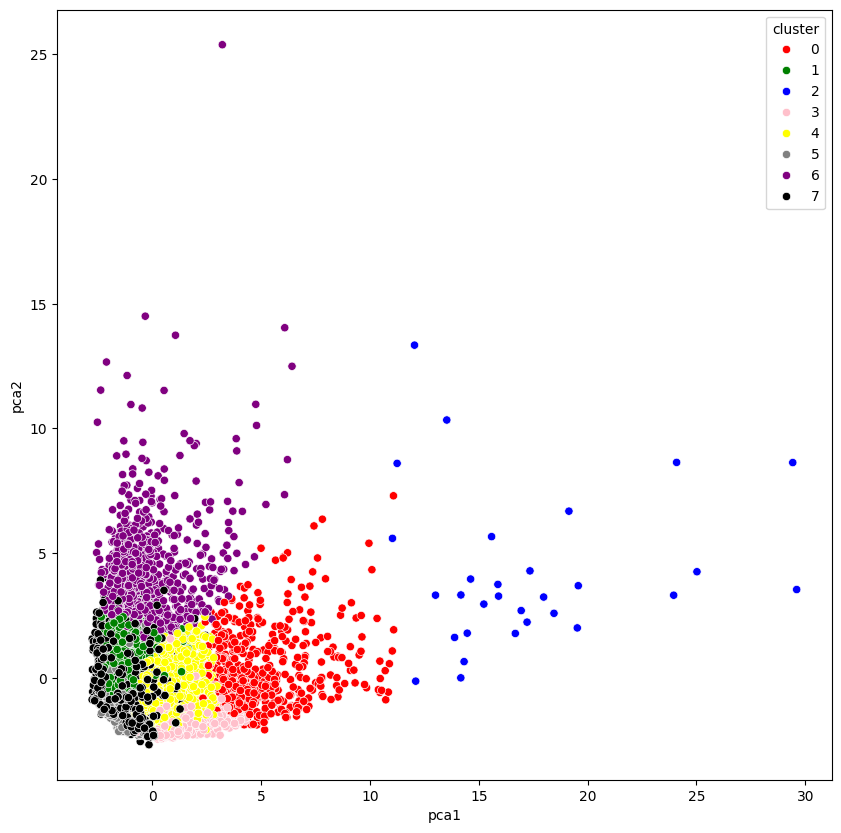

In [47]:
plt.figure(figsize=(10,10))
sns.scatterplot(x='pca1', 
                y='pca2', 
                hue='cluster', 
                data=pca_df, 
                palette = ['red', 'green', 'blue', 'pink', 'yellow', 'gray', 'purple', 'black']);

## Aplicação de autoencoders

In [48]:
creditcard_df_scaled.shape

(8950, 17)

In [49]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

2026-02-26 19:42:34.692090: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772134955.092288      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772134955.207550      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772134956.191731      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772134956.191788      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772134956.191791      24 computation_placer.cc:177] computation placer alr

In [50]:
input_df = Input(shape=(17,))
x = Dense(500, activation='relu')(input_df)
x = Dense(2000, activation='relu')(x)

encoded = Dense(10, activation='relu')(x)

x = Dense(2000, activation='relu')(encoded)
x = Dense(500, activation='relu')(x)

decoded = Dense(17)(x)

I0000 00:00:1772134990.431791      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772134990.437876      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [51]:
autoencoder = Model(input_df, decoded)

In [52]:
encoder = Model(input_df, encoded)

In [53]:
autoencoder.compile(optimizer = 'Adam', loss = 'mean_squared_error')

In [54]:
autoencoder.fit(creditcard_df_scaled, creditcard_df_scaled, epochs = 50)

Epoch 1/50


I0000 00:00:1772134994.443119      73 service.cc:152] XLA service 0x78db0400c430 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772134994.443158      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772134994.443162      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772134994.961297      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


 63/280 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5142

I0000 00:00:1772134996.657120      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


280/280 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.3117
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0788
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0654
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0949
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0445
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0361
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0471
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0412
Epoch 9/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0396
Epoch 10/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0348
Epoch 11/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0328
Epoch 12/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0276
Epoch 13/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0249
Epoch 14/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0444
Epoch 15/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0288


In [55]:
creditcard_df_scaled.shape

(8950, 17)

In [56]:
compact = encoder.predict(creditcard_df_scaled)

280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [57]:
compact.shape

(8950, 10)

In [58]:
creditcard_df_scaled[0]

array([-0.73198937, -0.24943448, -0.42489974, -0.35693402, -0.34907882,
       -0.46678555, -0.80649035, -0.67866081, -0.70731317, -0.67534886,
       -0.47606982, -0.51133325, -0.96043334, -0.52897879, -0.31096755,
       -0.52555097,  0.36067954])

In [59]:
compact[0]

array([0.        , 0.5215416 , 0.11619316, 0.21465926, 0.        ,
       0.6228364 , 0.18456826, 0.        , 0.42823237, 0.27341017],
      dtype=float32)

In [60]:
wcss_2 = []
range_values = range(1, 20)
for i in range_values:
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(compact)
  wcss_2.append(kmeans.inertia_)

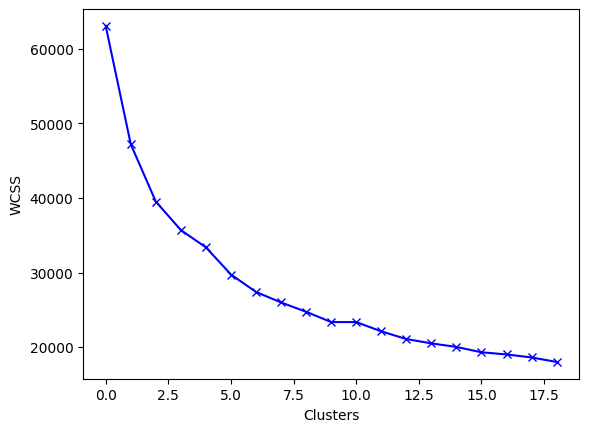

In [61]:
plt.plot(wcss_2, 'bx-')
plt.xlabel('Clusters')
plt.ylabel('WCSS');

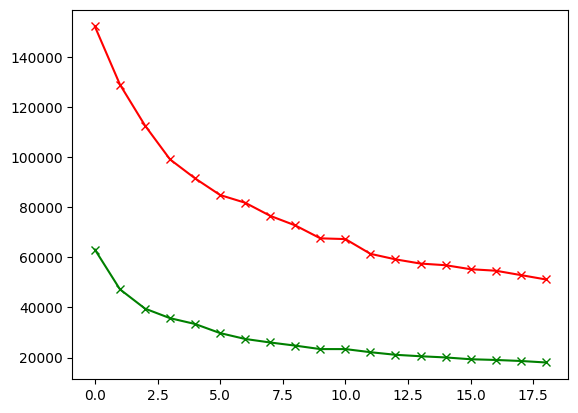

In [62]:
plt.plot(wcss_1, 'rx-')
plt.plot(wcss_2, 'gx-');

In [63]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(compact)

KMeans(n_clusters=4)

In [64]:
labels = kmeans.labels_
labels, labels.shape

(array([1, 2, 1, ..., 2, 2, 2], dtype=int32), (8950,))

In [65]:
df_cluster_at = pd.concat([creditcard_df, pd.DataFrame({'cluster': labels})], axis = 1)
df_cluster_at.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [66]:
pca = PCA(n_components = 2)
prin_comp = pca.fit_transform(compact)
pca_df = pd.DataFrame(data = prin_comp, columns = ['pca1', 'pca2'])
pca_df.head()

,pca1,pca2
0,-1.446474,0.010465
1,0.527467,1.511563
2,-0.867068,-0.457385
3,-0.888484,0.202134
4,-1.482539,-0.108261


In [67]:
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis = 1)
pca_df.head()

,pca1,pca2,cluster
0,-1.446474,0.010465,1
1,0.527467,1.511563,2
2,-0.867068,-0.457385,1
3,-0.888484,0.202134,1
4,-1.482539,-0.108261,1


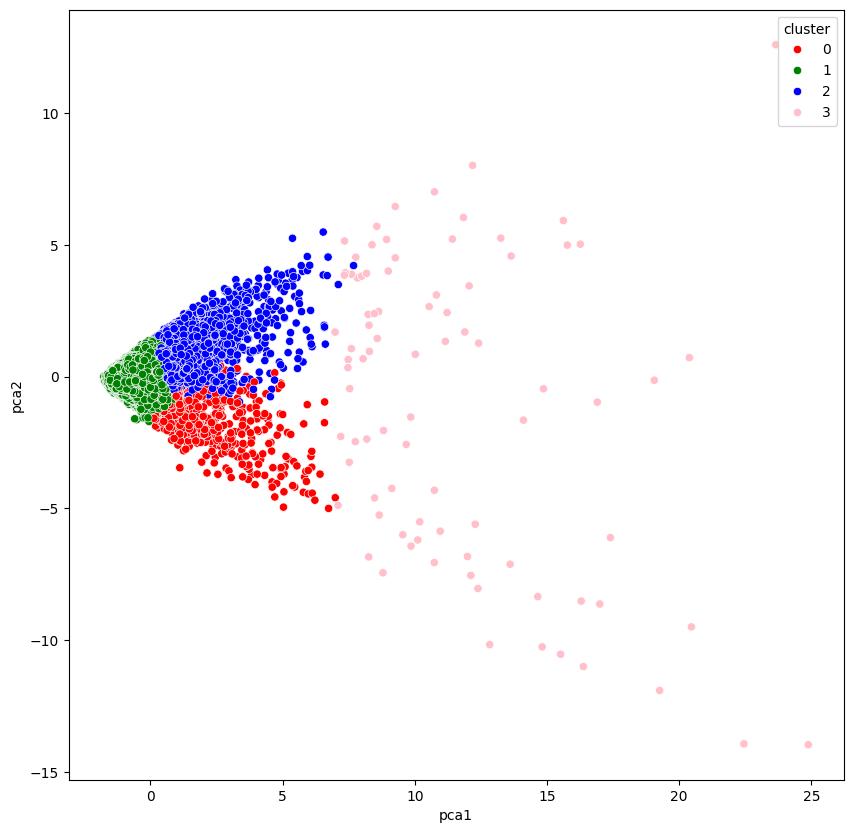

In [68]:
plt.figure(figsize=(10,10))
sns.scatterplot(x='pca1', 
                y='pca2', 
                hue='cluster', 
                data=pca_df, 
                palette=['red', 'green', 'blue', 'pink']);

In [69]:
df_cluster_ordered = df_cluster_at.sort_values(by = 'cluster')
df_cluster_ordered.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
938,391.179957,0.909091,7363.38,6965.06,398.32,0.000000,0.833333,0.666667,0.416667,0.000000,0,42,4500.0,11891.449070,889.957080,1.0,12,0
916,6725.109914,1.000000,6335.65,912.12,5423.53,0.000000,1.000000,0.583333,1.000000,0.000000,0,108,11000.0,3203.884297,2658.776690,0.0,12,0
919,542.051302,1.000000,4896.90,721.46,4175.44,960.975083,1.000000,0.416667,0.916667,0.083333,2,64,2500.0,5338.901791,173.182819,1.0,12,0
926,179.290727,1.000000,2540.90,1234.77,1306.13,0.000000,0.916667,0.833333,0.916667,0.000000,0,30,5000.0,2478.954766,168.750901,1.0,12,0
871,2767.545277,1.000000,3480.24,2767.28,712.96,0.000000,1.000000,1.000000,0.666667,0.000000,0,60,12500.0,4062.447703,1082.201074,0.0,12,0


In [70]:
df_cluster_ordered.tail()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
6067,1226.561937,0.857143,360.00,360.00,0.00,7883.541720,0.857143,0.857143,0.0,0.857143,30,6,2500.0,10132.43236,920.287770,0.600,7,3
970,3108.393701,0.900000,26582.34,15158.90,11423.44,0.000000,0.900000,0.800000,0.8,0.000000,0,55,28000.0,26557.09724,586.029097,0.875,10,3
610,7155.328723,1.000000,3837.59,1860.18,1977.41,14811.688180,1.000000,0.916667,1.0,0.916667,51,52,9500.0,17739.94594,2500.582848,0.000,12,3
1256,4010.621974,1.000000,40040.71,24543.52,15497.19,0.000000,1.000000,1.000000,1.0,0.000000,0,358,18000.0,33994.72785,703.503256,1.000,12,3
6028,4507.000722,1.000000,7394.18,2288.20,5105.98,5424.701791,1.000000,0.916667,1.0,0.833333,40,130,11000.0,10460.87946,1076.589500,0.000,12,3


In [71]:
df_cluster_ordered.to_excel('cluster_ordereded.xlsx')